
NETFLIX MOVIES & TV SHOWS — DATA ANALYSIS

1. DATA PREPARATION
[Successfully loaded: Netflix_shows_movies]
✓ Dataset shape: 6234 rows, 12 columns
✓ Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 5 rows:
    show_id     type                                    title  \
0  81145628    Movie  Norm of the North: King Sized Adventure   
1  80117401    Movie               Jandino: Whatever it Takes   
2  70234439  TV Show                       Transformers Prime   
3  80058654  TV Show         Transformers: Robots in Disguise   
4  80125979    Movie                             #realityhigh   

                   director  \
0  Richard Finn, Tim Maltby   
1                       NaN   
2                       NaN   
3                       NaN   
4          Fernando Lebrija   

                                                cast  \
0  Alan Marriott, Andrew Toth, Brian Dobson, Cole... 

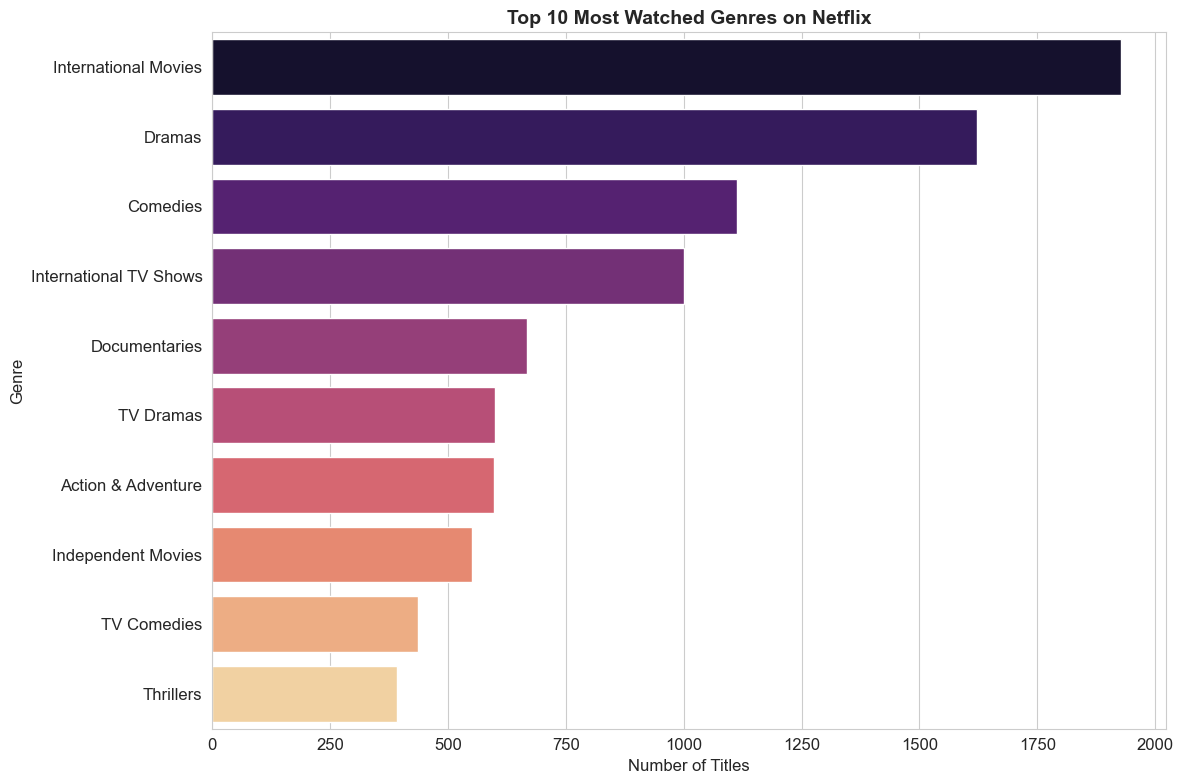


[SAVED] most_watched_genres.png

Creating: Ratings Distribution Visualization...


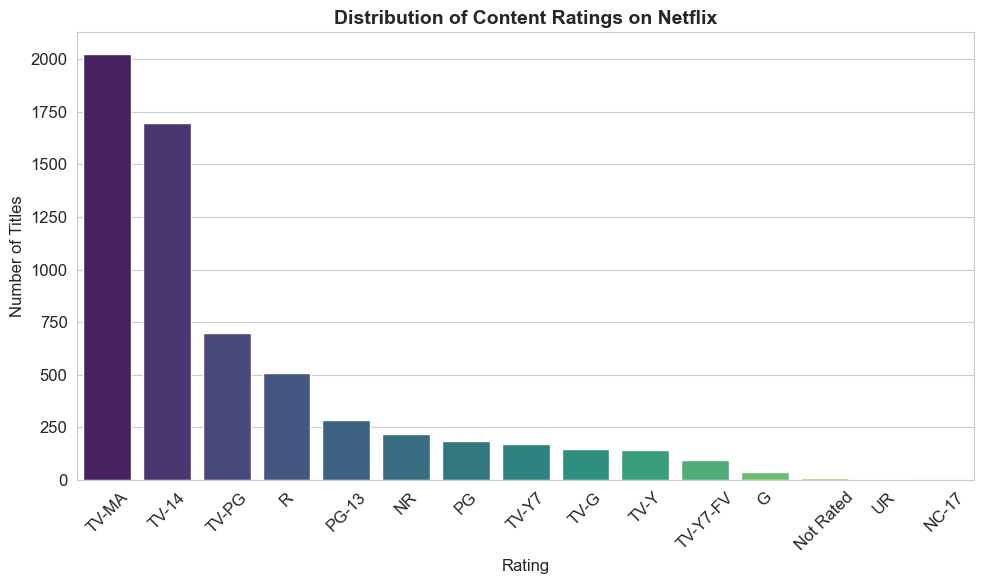


[SAVED] ratings_distribution.png

Creating: Content Type Distribution...


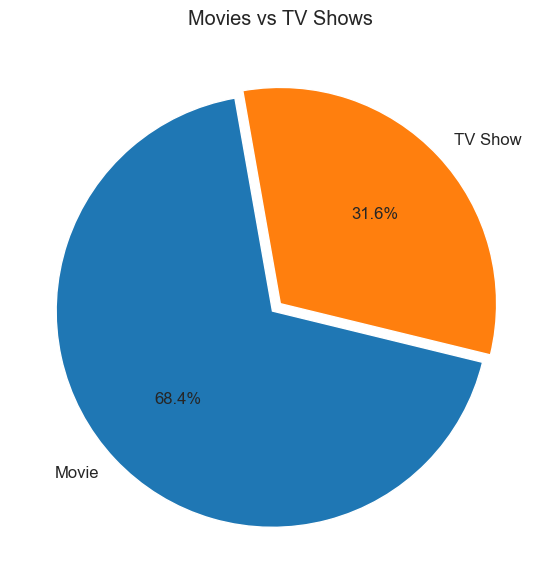


[SAVED] content_type_distribution.png

5. SAVED CLEANED DATASET

[Cleaned dataset saved successfully]

[Analysis Completed Successfully!]


In [193]:
# ==========================================================
# Module 4 Assignment: Netflix Movies & TV Shows Analysis
# Author: Sodiq Omoniyi
# ==========================================================

# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 50)
print("NETFLIX MOVIES & TV SHOWS — DATA ANALYSIS")
print("=" * 50)

# ----------------------------------------------------------
# 1. DATA PREPARATION
# ----------------------------------------------------------
print("\n" + "=" * 50)
print("1. DATA PREPARATION")
print("=" * 50)

# Load the CSV file directly
try:
    Netflix_shows_movies = pd.read_csv('~/Downloads/netflix_data.csv')
    print("[Successfully loaded: Netflix_shows_movies]")
except FileNotFoundError:
    print("CSV file not found. Please check the file path.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    exit()

# Display basic information
print(f"✓ Dataset shape: {Netflix_shows_movies.shape[0]} rows, {Netflix_shows_movies.shape[1]} columns")
print(f"✓ Columns: {list(Netflix_shows_movies.columns)}")
print("\nFirst 5 rows:")
print(Netflix_shows_movies.head())

# ----------------------------------------------------------
# 2. DATA CLEANING
# ----------------------------------------------------------
print("\n" + "=" * 50)
print("2. DATA CLEANING")
print("=" * 50)

print("\n[Missing Values Before Cleaning]:")
print(Netflix_shows_movies.isnull().sum())

# Handle missing values
# For 'director', 'cast', 'country', 'date_added', 'rating', 'duration'
# Fill with 'Unknown' or appropriate values
for col in ["director", "cast", "country", "date_added", "duration"]:
    Netflix_shows_movies[col] = Netflix_shows_movies[col].fillna("Unknown")
Netflix_shows_movies['rating'] = Netflix_shows_movies['rating'].fillna('Not Rated')

# Remove duplicate rows
Netflix_shows_movies.drop_duplicates(inplace=True)

print("\n[Missing Values After Cleaning]:")
print(Netflix_shows_movies.isnull().sum())

# ─────────────────────────────────────────────
# 3. DATA EXPLORATION
# ─────────────────────────────────────────────
print("\n" + "=" * 50)
print("3. DATA EXPLORATION")
print("=" * 50)

print("\n[Dataset Information]:")
print(Netflix_shows_movies.info())

print("\n[Dataset Shape]:")
print(Netflix_shows_movies.shape)

print("\n[Column Names]:")
print(Netflix_shows_movies.columns)

print("\n[Statistical Summary]:")
print(Netflix_shows_movies.describe(include="all"))

print("\n[Contents Type Distribution]:")
print(Netflix_shows_movies["type"].value_counts())

print("\n[Ratings Distribution]:")
print(Netflix_shows_movies["rating"].value_counts())

print("\n[Top 10 Countries]:")
print(Netflix_shows_movies["country"].value_counts().head(10))

print("\n[Release Years Summary]:")
print(Netflix_shows_movies["release_year"].describe())

print("\n[Top 10 Release Years by Contents]:")
print(Netflix_shows_movies['release_year'].value_counts().head(10))

# ─────────────────────────────────────────────
# 4. DATA VISUALIZATION
# ─────────────────────────────────────────────
print("\n" + "=" * 50)
print("4. DATA VISUALIZATION")
print("=" * 50)

# Set plot style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
# ----------------------------------------------------------
# Visualization 1: Most Watched Genres
# ----------------------------------------------------------
print("\n[Creating: Most Watched Genres Visualization...]")
# Genres are comma-separated in 'listed_in'; split and explode them
genres_series = Netflix_shows_movies['listed_in'].str.split(', ').explode()
top_genres = genres_series.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title('Top 10 Most Watched Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('most_watched_genres.png')
plt.show()
print("\n[SAVED] most_watched_genres.png")

# ----------------------------------------------------------
# Visualization 2: Ratings Distribution
# ----------------------------------------------------------
print("\nCreating: Ratings Distribution Visualization...")
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=Netflix_shows_movies, order=Netflix_shows_movies['rating'].value_counts().index, palette='viridis')
plt.title('Distribution of Content Ratings on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ratings_distribution.png')
plt.show()
print("\n[SAVED] ratings_distribution.png")

# ----------------------------------------------------------
# Additional Visualization: Content Type Distribution
# ----------------------------------------------------------
print("\nCreating: Content Type Distribution...")
plt.figure(figsize=(6,6))
Netflix_shows_movies["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=100,
    explode=(0.05, 0)
)

plt.ylabel("")
plt.title("Movies vs TV Shows")
plt.tight_layout()
plt.savefig("content_type_distribution.png")
plt.show()
print("\n[SAVED] content_type_distribution.png")

# ─────────────────────────────────────────────
# 5. SAVED CLEANED DATASET
# ─────────────────────────────────────────────
print("\n" + "=" * 50)
print("5. SAVED CLEANED DATASET")
print("=" * 50)
try:
    Netflix_shows_movies.to_csv(
        "Netflix_shows_movies_cleaned.csv",
        index=False
    )
    print("\n[Cleaned dataset saved successfully]")
except Exception as e:
    print(f"Unable to save cleaned dataset: {e}")

print("\n[Analysis Completed Successfully!]")